In [ ]:
!pip install dask[complete]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.8 MB/s eta 0:00:00


In [ ]:
import dask.dataframe as dd


In [ ]:
!pip install mlxtend

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")


In [ ]:
import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
customers = dd.read_csv("data/archive/olist_customers_dataset.csv", assume_missing=True)
orders = dd.read_csv("data/archive/olist_orders_dataset.csv", assume_missing=True)
order_items = dd.read_csv("data/archive/olist_order_items_dataset.csv", assume_missing=True)
products = dd.read_csv("data/archive/olist_products_dataset.csv", assume_missing=True)
payments = dd.read_csv("data/archive/olist_order_payments_dataset.csv", assume_missing=True)
category_translation = dd.read_csv("data/archive/product_category_name_translation.csv", assume_missing=True)



In [ ]:
df = orders.merge(customers, on="customer_id")
df = df.merge(order_items, on="order_id")
df = df.merge(products, on="product_id", how="left")
df = df.merge(category_translation, on="product_category_name", how="left")
df = df.merge(payments, on="order_id", how="left")


In [ ]:
df = df[df["order_status"] == "delivered"]


In [ ]:
df["product_category_name_english"] = df["product_category_name_english"].fillna("Unknown")


In [ ]:
df["order_purchase_timestamp"] = dd.to_datetime(df["order_purchase_timestamp"])


In [ ]:
df["TotalPrice"] = df["price"] + df["freight_value"]


In [ ]:
df["Month"] = df["order_purchase_timestamp"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum().compute()


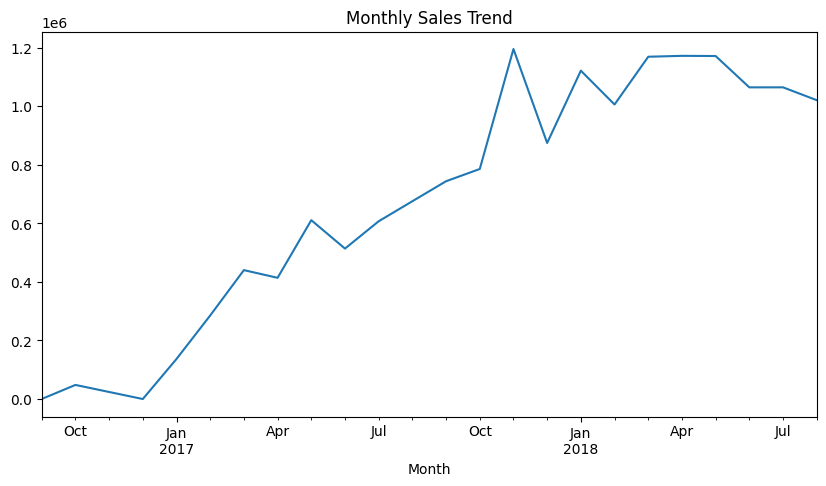

In [ ]:
plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()


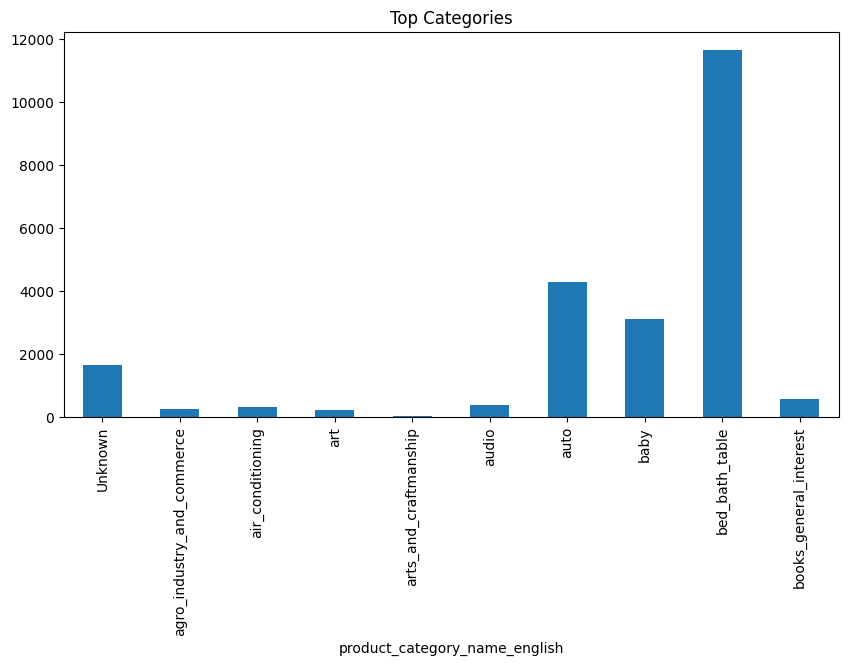

In [ ]:
top_categories = df["product_category_name_english"].value_counts().compute().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top Categories")
plt.show()


In [ ]:
total_spending = df.groupby("customer_unique_id")["TotalPrice"].sum()


In [ ]:
purchase_frequency = df.groupby("customer_unique_id")["order_id"].nunique()


In [ ]:
customer_data = dd.concat([total_spending, purchase_frequency], axis=1).compute()


In [ ]:
customer_data.columns = ["TotalSpending", "PurchaseFrequency"]


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
customer_data["Cluster"] = kmeans.fit_predict(customer_data)


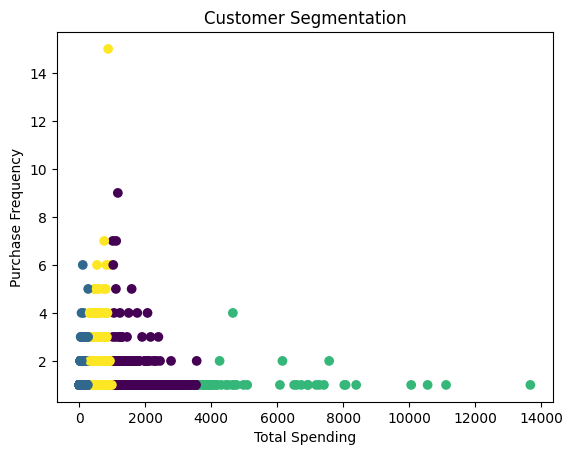

In [ ]:
plt.scatter(customer_data["TotalSpending"],
            customer_data["PurchaseFrequency"],
            c=customer_data["Cluster"])
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")
plt.title("Customer Segmentation")
plt.show()


In [ ]:
top_categories = df["product_category_name_english"].value_counts().compute().head(10).index

filtered_df = df[df["product_category_name_english"].isin(top_categories)]


In [ ]:
basket = filtered_df.groupby(
    ["order_id", "product_category_name_english"]
)["order_item_id"].count().unstack().fillna(0)

basket = (basket > 0)

basket.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

product_category_name_english,Unknown,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest
order_id,,,,,,,,,,
0006ec9db01a64e59a68b2c340bf65a7,False,False,False,False,False,False,False,False,True,False
000e63d38ae8c00bbcb5a30573b99628,False,False,False,False,False,False,False,False,True,False
00137e170939bba5a3134e2386413108,False,True,False,False,False,False,False,False,False,False
00169e31ef4b29deaae414f9a5e95929,False,False,False,False,False,False,False,False,True,False
001c85b5f68d2be0cb0797afc9e8ce9a,False,False,False,False,False,False,False,False,True,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(basket, min_support=0.002, use_colnames=True)

rules = association_rules(frequent_items, metric="lift", min_threshold=1)

print("Frequent Itemsets:")
display(frequent_items.head())

print("\nAssociation Rules:")
display(rules.head())


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Frequent Itemsets:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.075279,(Unknown)
1,0.009436,(agro_industry_and_commerce)
2,0.013115,(air_conditioning)
3,0.010396,(art)
4,0.018553,(audio)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Association Rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag